### Perceptron can be used in many different wyas based on the Loss function and activation function chosen such as :
- Linear Regression - if activation function is linear and loss function is MSE, RMSE, etc, output is continuous numerical
- Logistic Regression - if activation function is sigmoid and loss function is binary cross entropy loss, output is probability betn 0 and 1
- Softmax Regression -  if activation function is softmax and loss function is categorical cross entropy loss, output is probability betn 0 and 1 for each class, which ever is highest is considered as a predicted class
- Perceptron -  if activation function is step and loss function is hinge loss, output is either -1 or 1

In all of these SGD (Stochastic Gradient Descent) can be used as an optimizer for optimizing weights and bias

In [6]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

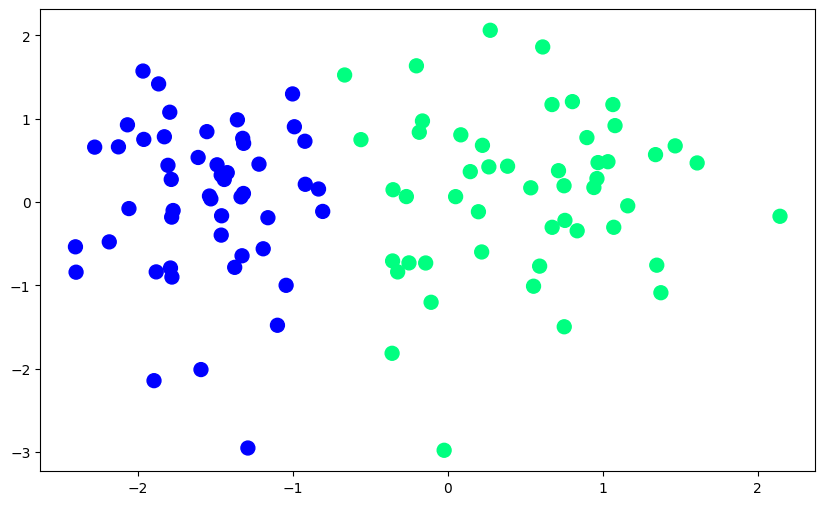

In [14]:
# Making a dummy classification dataset

X, Y = make_classification(
    n_classes=2,
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    n_repeated=0,
    random_state=41,
    class_sep=10,
    hypercube=False
) 

plt.figure(figsize=(10, 6))
plt.scatter(x=X[:,0], y=X[:, 1], c=Y, cmap="winter", s=100)
plt.show()

In [19]:
print("Shape of feature dataset : ", X.shape)
print("First 5 rows of X = ", X[:5])
print("First 5 rows of Y = ", Y[:5])

Shape of feature dataset :  (100, 2)
First 5 rows of X =  [[ 0.19924745 -0.11697552]
 [-0.24882029 -0.73115232]
 [-0.3544904  -0.7081059 ]
 [-1.59086506 -2.01199214]
 [-0.20083951  1.63493163]]
First 5 rows of Y =  [1 1 1 0 1]


In [ ]:
def step(z):
    return 1 if z >= 0 else 0 

def perceptron(X, Y, epochs, lr):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])

    for j in range(epochs):
        i = np.random.randint(1, X.shape[0])
        y_hat_i = step(np.dot(X[i], weights))
        weights = weights + lr * (Y[i] - y_hat_i) * X[i]        # not gradient descent

    return weights[0], weights[1:]  


In [23]:
intercept, coef = perceptron(X, Y, epochs=1000, lr=0.01)

In [24]:
print(intercept)
print(coef)

0.94
[1.29605249 0.25664798]


In [25]:
# To plot we need slope and y-intercept
m = - (coef[0] / coef[1])
b = - (intercept / coef[1])

print("Slope : ", m, " and Y-intercept : ", b)

Slope :  -5.049922754186251  and Y-intercept :  -3.6626042840749395


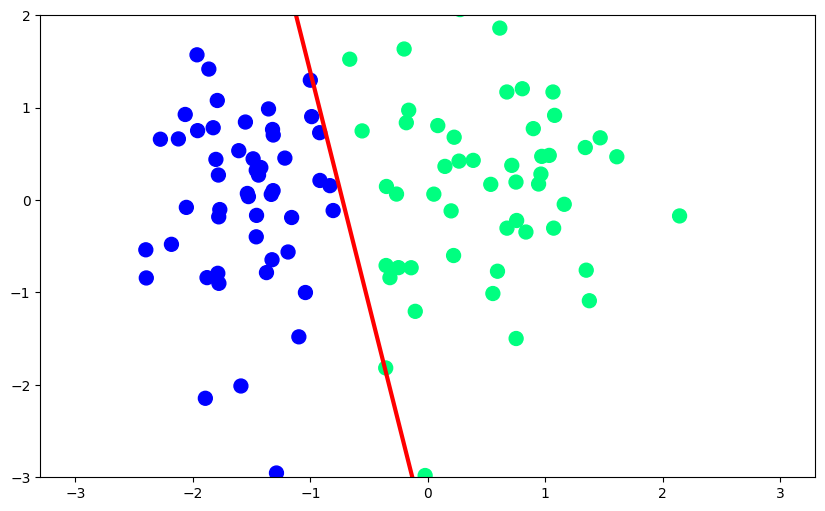

In [27]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color="red", linewidth=3)
plt.scatter(x=X[:,0], y=X[:, 1], c=Y, cmap="winter", s=100)
plt.ylim(-3, 2)
plt.show()